In [54]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [55]:
pip install keras-preprocessing

Note: you may need to restart the kernel to use updated packages.


In [56]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np

In [57]:
TRAIN_DIR ='images/train'
TEST_DIR='images/test'

In [58]:
def createdataframe(dir):
    image_paths=[]
    labels=[]
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
            print(label,"completed")
    return image_paths,labels

In [59]:
train=pd.DataFrame()
train['image'],train['label']=createdataframe(TRAIN_DIR)

angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry co

In [60]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [61]:
test=pd.DataFrame()
test['image'],test['label']=createdataframe(TEST_DIR)

angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry completed
angry co

In [62]:
print(test)
print(test['image'])


                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]
0         images/test\angry\10052.jpg
1         images/test\angry\10065.jpg
2         images/test\angry\10079.jpg
3         images/test\angry\10095.jpg
4         images/test\angry\10121.jpg
                    ...              
7061    images/test\surprise\9806.jpg
7062    images/test\surprise\9830.jpg
7063    images/test\surprise\9853.jpg
7064    images/test\surprise\9878.jpg
7065     images/test\surprise\993.jpg
Name:

In [63]:
!pip install pillow

In [64]:
from PIL import Image
print("Pillow working")

Pillow working


In [65]:
!pip install tqdm

In [66]:
from tqdm.notebook import tqdm
def extract_features(images):
    features=[]
    for image in tqdm(images):
        img=load_img(image,color_mode='grayscale')
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features= features.reshape(len(features),48,48,1)
    return features
        
    

In [67]:
train_features = extract_features(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

In [68]:
test_features= extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [69]:
x_train=train_features/255.0
x_test=test_features/255.0

In [70]:
!pip install scikit-learn


In [71]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [72]:
y_train = le.transform(train['label'])
y_test=le.transform(test['label'])

In [73]:
y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)


In [74]:
model = Sequential()

#convolutional Layers

model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,kernel_size=(3,3),activation='relu',))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(152,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())

#fully connected Layers

model.add(Dense(512,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.4))

#output layer
model.add(Dense(7,activation='softmax'))

In [75]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [76]:
model.fit(x=x_train ,y=y_train, batch_size=128, epochs =100, validation_data=(x_test,y_test))

Epoch 1/100
226/226 [==============================] - 139s 607ms/step - loss: 1.8261 - accuracy: 0.2431 - val_loss: 1.8113 - val_accuracy: 0.2583
Epoch 2/100
226/226 [==============================] - 138s 610ms/step - loss: 1.8023 - accuracy: 0.2491 - val_loss: 1.7756 - val_accuracy: 0.2621
Epoch 3/100
226/226 [==============================] - 135s 598ms/step - loss: 1.7418 - accuracy: 0.2813 - val_loss: 1.6764 - val_accuracy: 0.3217
Epoch 4/100
226/226 [==============================] - 139s 617ms/step - loss: 1.6695 - accuracy: 0.3310 - val_loss: 1.5503 - val_accuracy: 0.3971
Epoch 5/100
226/226 [==============================] - 136s 600ms/step - loss: 1.5793 - accuracy: 0.3790 - val_loss: 1.4723 - val_accuracy: 0.4396
Epoch 6/100
226/226 [==============================] - 136s 602ms/step - loss: 1.5192 - accuracy: 0.4057 - val_loss: 1.3946 - val_accuracy: 0.4667
Epoch 7/100
226/226 [==============================] - 137s 605ms/step - loss: 1.4734 - accuracy: 0.4287 - val_loss: 1

In [77]:
model_json=model.to_json()
with open("emotiondetector.json",'w')as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")

D:\face_emotion_detection\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [89]:
from keras.models import model_from_json

In [90]:
json_file=open("emotiondetector.json","r")
model_json = json_file.read()
json_file.close()
model= model_from_json(model_json)
model.load_weights("emotiondetector.h5")


In [91]:
label=['angry','disgust','fear','happy','neutral','sad','surprise']

In [92]:
def ef(image):
    img= load_img(image,color_mode='grayscale')
    feature=np.array(img)
    feature=feature.reshape(1,48,48,1)
    return feature/255.0

In [93]:
image ='images/train/angry/22.jpg'
print("original image is of angry")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is ", pred_label)

original image is of angry
1/1 [==============================] - 0s 176ms/step
model prediction is  angry


In [94]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of angry
1/1 [==============================] - 0s 35ms/step
model prediction is  angry


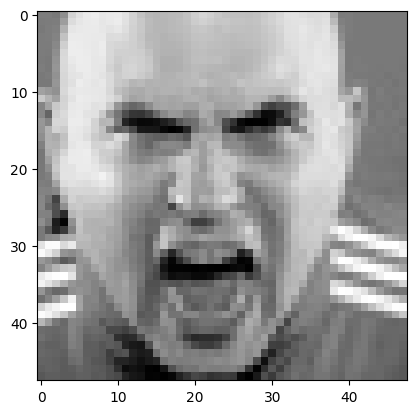

In [95]:
image ='images/train/angry/22.jpg'
print("original image is of angry")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is ", pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of fear
1/1 [==============================] - 0s 50ms/step
model prediction is  sad


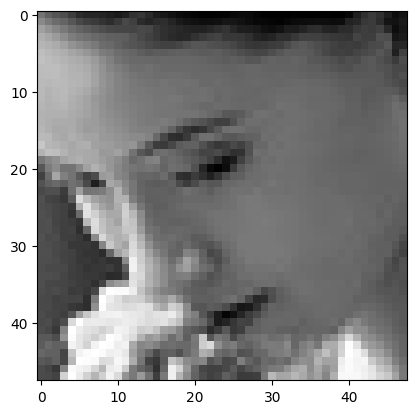

In [96]:
image ='images/train/fear/10010.jpg'
print("original image is of fear")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is ", pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

In [97]:
import os
print(os.listdir("images/train/fear")[:20])

['10010.jpg', '10012.jpg', '10015.jpg', '10025.jpg', '10032.jpg', '10040.jpg', '10047.jpg', '10055.jpg', '10067.jpg', '10072.jpg', '10075.jpg', '10086.jpg', '10088.jpg', '10090.jpg', '10107.jpg', '10123.jpg', '10125.jpg', '1013.jpg', '10131.jpg', '10147.jpg']


In [98]:
import os
print(os.listdir("images/train/sad")[:20])

['10006.jpg', '10008.jpg', '1001.jpg', '10020.jpg', '10028.jpg', '10034.jpg', '10049.jpg', '1005.jpg', '10059.jpg', '10064.jpg', '1007.jpg', '10070.jpg', '10078.jpg', '10081.jpg', '10089.jpg', '1009.jpg', '1010.jpg', '10103.jpg', '10108.jpg', '1011.jpg']


original image is of sad
1/1 [==============================] - 0s 45ms/step
model prediction is  sad


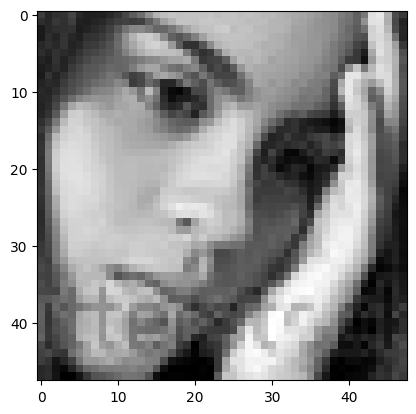

In [99]:
image ='images/train/sad/1001.jpg'
print("original image is of sad")
img=ef(image)
pred=model.predict(img)
pred_label=label[pred.argmax()]
print("model prediction is ", pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')